In [1]:
from pathlib import Path

# ====== YOU SET THESE 3 THINGS ======
ROOT = Path("/data/shared/fsibilla/clean_code/Q1/experiments")
EXP_NAME = "yem_mvam"                 # {country}_{datasets}
TRAIN_PERCENTS = ['10','20','40','80']     # the 4 values you have
# ====================================

# Which split files to use (train/test naming)
SPLIT = "train"  # you used eval_adm1_seed_metrics_train_{train_percent}.csv

# How to define improvement (baseline vs gen):
#   "diff": baseline - gen  (positive means baseline worse than gen if lower is better? Actually: if metric lower is better, baseline-gen >0 => gen better)
#   "rel":  (baseline - gen) / baseline
improvement_def = "diff"

In [2]:
import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

EVAL_DIR = ROOT / EXP_NAME / "results" / "evaluation"
pattern = rf"eval_adm1_seed_metrics_{SPLIT}_(.+)\.csv"

files = sorted(EVAL_DIR.glob(f"eval_adm1_seed_metrics_{SPLIT}_*.csv"))

found = {}
for p in files:
    m = re.match(pattern, p.name)
    if m:
        tp = m.group(1)   # keep it as string, do NOT cast to int
        found[tp] = p

missing = [tp for tp in TRAIN_PERCENTS if tp not in found]
if missing:
    raise FileNotFoundError(
        f"Missing train percents in {EVAL_DIR}: {missing}\n"
        f"Found: {sorted(found)}"
    )

print("Found files:")
for tp in TRAIN_PERCENTS:
    print(f"{tp} -> {found[tp].name}")

Found files:
10 -> eval_adm1_seed_metrics_train_10.csv
20 -> eval_adm1_seed_metrics_train_20.csv
40 -> eval_adm1_seed_metrics_train_40.csv
80 -> eval_adm1_seed_metrics_train_80.csv


In [3]:
# columns needed (avoid loading huge geometry)
usecols = [
    "seed", "adm1_code", "adm1_name", "target",
    "emd_gen", "emd_nat", "emd_over",
    "absmeanerr_gen", "absmeanerr_nat", "absmeanerr_over"
]

rows = []
for tp in TRAIN_PERCENTS:
    p = found[tp]
    df = pd.read_csv(p, usecols=usecols)
    df["train_percent"] = tp
    rows.append(df)

raw = pd.concat(rows, ignore_index=True)

# Long/tidy: 4 metric-baseline combos
# combos: (metric, baseline) in {"emd","absmeanerr"} x {"nat","over"}
def compute_improvement(df: pd.DataFrame, metric: str, baseline: str) -> pd.Series:
    gen_col = f"{metric}_gen"
    base_col = f"{metric}_{baseline}"
    if improvement_def == "diff":
        return df[base_col] - df[gen_col]
    elif improvement_def == "rel":
        return (df[base_col] - df[gen_col]) / df[base_col].replace(0, np.nan)
    else:
        raise ValueError("improvement_def must be 'diff' or 'rel'")

tidy_parts = []
for metric in ["emd", "absmeanerr"]:
    for baseline in ["nat", "over"]:
        tmp = raw[["seed","adm1_code","adm1_name","target","train_percent"]].copy()
        tmp["metric"] = metric
        tmp["baseline"] = baseline
        tmp["improvement"] = compute_improvement(raw, metric, baseline)
        tidy_parts.append(tmp)

tidy = pd.concat(tidy_parts, ignore_index=True)
tidy.head()

,seed,adm1_code,adm1_name,target,train_percent,metric,baseline,improvement
0,1,Abyan,Abyan,log_exp_pp,10,emd,nat,0.182096
1,1,Abyan,Abyan,rCSI,10,emd,nat,0.030674
2,1,Abyan,Abyan,FCS,10,emd,nat,-0.026800
3,1,Ad Dali',Ad Dali',log_exp_pp,10,emd,nat,-0.104180
4,1,Ad Dali',Ad Dali',rCSI,10,emd,nat,0.007146


In [4]:
# Average over seeds: mean + standard error across seeds
seed_agg = (
    tidy
    .groupby(["train_percent","target","adm1_code","adm1_name","metric","baseline"], as_index=False)
    .agg(
        mean=("improvement","mean"),
        sd=("improvement","std"),
        n=("improvement","count"),
    )
)

seed_agg["se"] = seed_agg["sd"] / np.sqrt(seed_agg["n"].clip(lower=1))

# helpful ordering
seed_agg = seed_agg.sort_values(["target","metric","baseline","adm1_code","train_percent"]).reset_index(drop=True)
seed_agg.head()

,train_percent,target,adm1_code,adm1_name,metric,baseline,mean,sd,n,se
0,10,FCS,Abyan,Abyan,absmeanerr,nat,-0.138980,0.439111,5,0.196377
1,20,FCS,Abyan,Abyan,absmeanerr,nat,0.225393,0.413560,5,0.184950
2,40,FCS,Abyan,Abyan,absmeanerr,nat,0.277537,0.332587,5,0.148737
3,80,FCS,Abyan,Abyan,absmeanerr,nat,0.307547,0.321465,5,0.143763
4,10,FCS,Ad Dali',Ad Dali',absmeanerr,nat,0.131677,0.442161,5,0.197740


/tmp/ipykernel_155552/2858306578.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


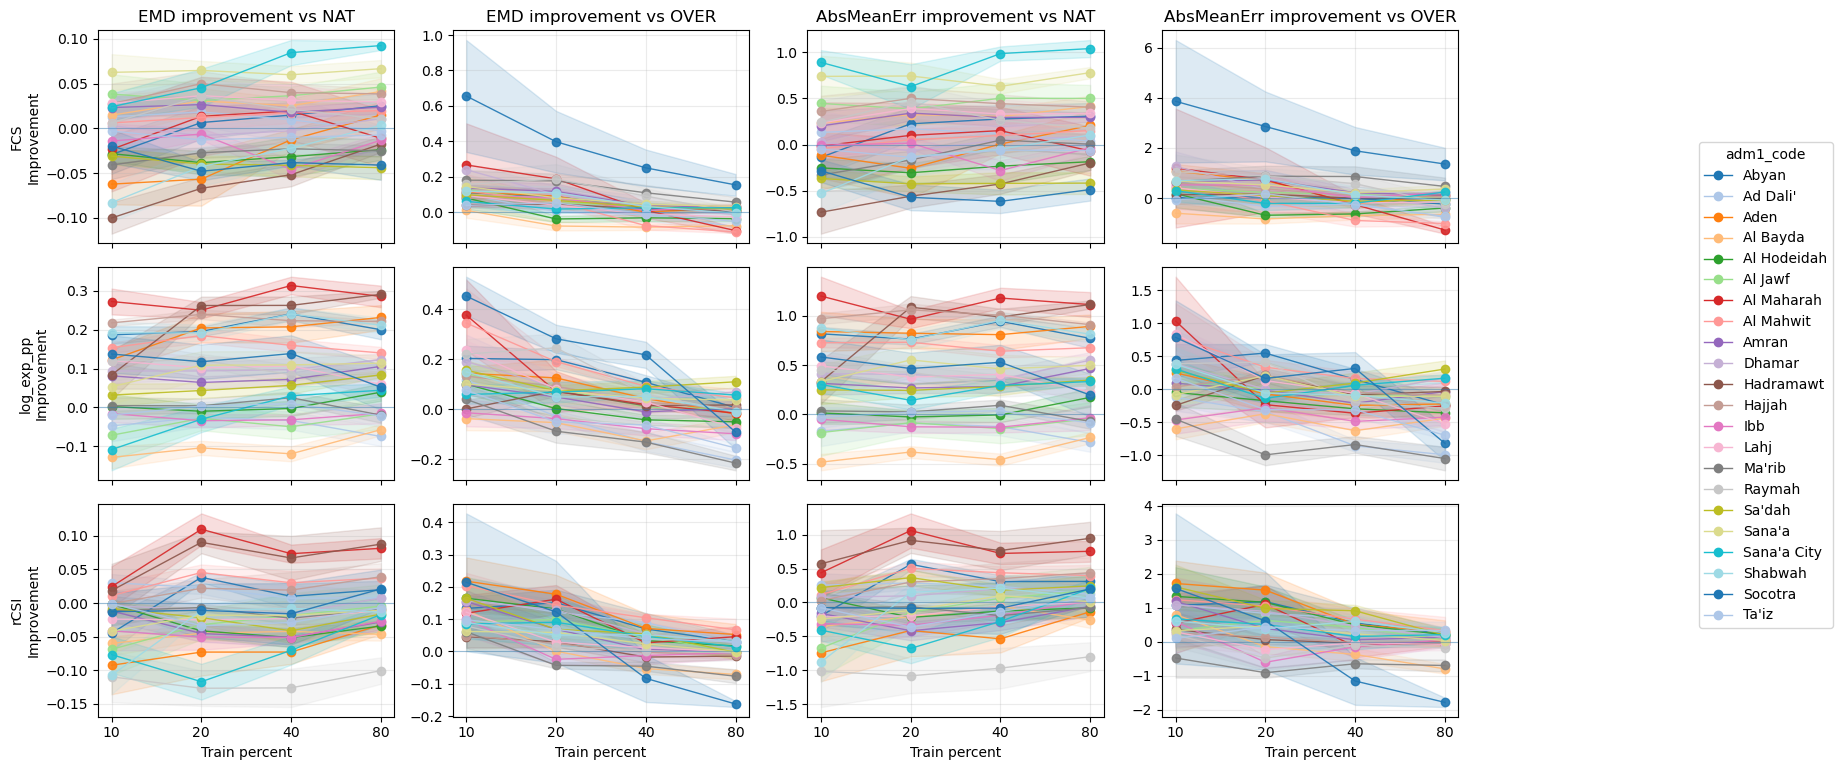

In [5]:
from math import ceil

COMBOS = [("emd","nat"), ("emd","over"), ("absmeanerr","nat"), ("absmeanerr","over")]
combo_titles = {
    ("emd","nat"): "EMD improvement vs NAT",
    ("emd","over"): "EMD improvement vs OVER",
    ("absmeanerr","nat"): "AbsMeanErr improvement vs NAT",
    ("absmeanerr","over"): "AbsMeanErr improvement vs OVER",
}

targets = sorted(seed_agg["target"].unique())
adm1s = seed_agg[["adm1_code","adm1_name"]].drop_duplicates().sort_values("adm1_code")

# color map for adm1
cmap = get_cmap("tab20")
adm1_codes = adm1s["adm1_code"].tolist()
color_map = {code: cmap(i % cmap.N) for i, code in enumerate(adm1_codes)}

nrows = len(targets)
ncols = len(COMBOS)

fig_w = 4.2 * ncols
fig_h = max(2.6 * nrows, 3.2)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=True)

if nrows == 1:
    axes = np.array([axes])

for r, target in enumerate(targets):
    for c, (metric, baseline) in enumerate(COMBOS):
        ax = axes[r, c]
        sub = seed_agg[(seed_agg["target"] == target) & (seed_agg["metric"] == metric) & (seed_agg["baseline"] == baseline)]

        for adm1_code in adm1_codes:
            s2 = sub[sub["adm1_code"] == adm1_code].sort_values("train_percent")
            if s2.empty:
                continue
            x = s2["train_percent"].to_numpy()
            y = s2["mean"].to_numpy()
            se = s2["se"].to_numpy()

            ax.plot(x, y, marker="o", linewidth=1.0, alpha=0.9, color=color_map[adm1_code])
            ax.fill_between(x, y - se, y + se, alpha=0.15, color=color_map[adm1_code])

        if r == 0:
            ax.set_title(combo_titles[(metric, baseline)])
        if c == 0:
            ax.set_ylabel(f"{target}\nImprovement")
        ax.axhline(0, linewidth=0.8, alpha=0.4)
        ax.grid(True, alpha=0.25)

for ax in axes[-1, :]:
    ax.set_xlabel("Train percent")

# legend (one per figure)
handles = []
labels = []
for code, name in zip(adm1s["adm1_code"], adm1s["adm1_name"]):
    h = plt.Line2D([0], [0], color=color_map[code], marker="o", linewidth=1.0)
    handles.append(h)
    labels.append(str(code))

fig.legend(handles, labels, title="adm1_code", loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout(rect=[0, 0, 0.88, 1])

plt.show()

In [6]:
def aggregate_means_with_se(df: pd.DataFrame, group_cols: list, mean_col="mean", se_col="se") -> pd.DataFrame:
    def _agg(g):
        means = g[mean_col].to_numpy()
        ses = g[se_col].to_numpy()
        n = len(means)
        out_mean = np.nanmean(means)
        out_se = np.sqrt(np.nansum(ses**2)) / max(n, 1)
        return pd.Series({"mean": out_mean, "se": out_se, "n": n})

    return df.groupby(group_cols, as_index=False).apply(_agg).reset_index(drop=True)

adm1_avg = aggregate_means_with_se(
    seed_agg,
    group_cols=["train_percent","target","metric","baseline"]
).sort_values(["target","metric","baseline","train_percent"]).reset_index(drop=True)

adm1_avg.head()

/tmp/ipykernel_155552/1536647084.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, as_index=False).apply(_agg).reset_index(drop=True)


,train_percent,target,metric,baseline,mean,se,n
0,10,FCS,absmeanerr,nat,0.028512,0.044576,22.0
1,20,FCS,absmeanerr,nat,0.077813,0.036894,22.0
2,40,FCS,absmeanerr,nat,0.109564,0.031557,22.0
3,80,FCS,absmeanerr,nat,0.154203,0.024336,22.0
4,10,FCS,absmeanerr,over,0.627387,0.179588,22.0


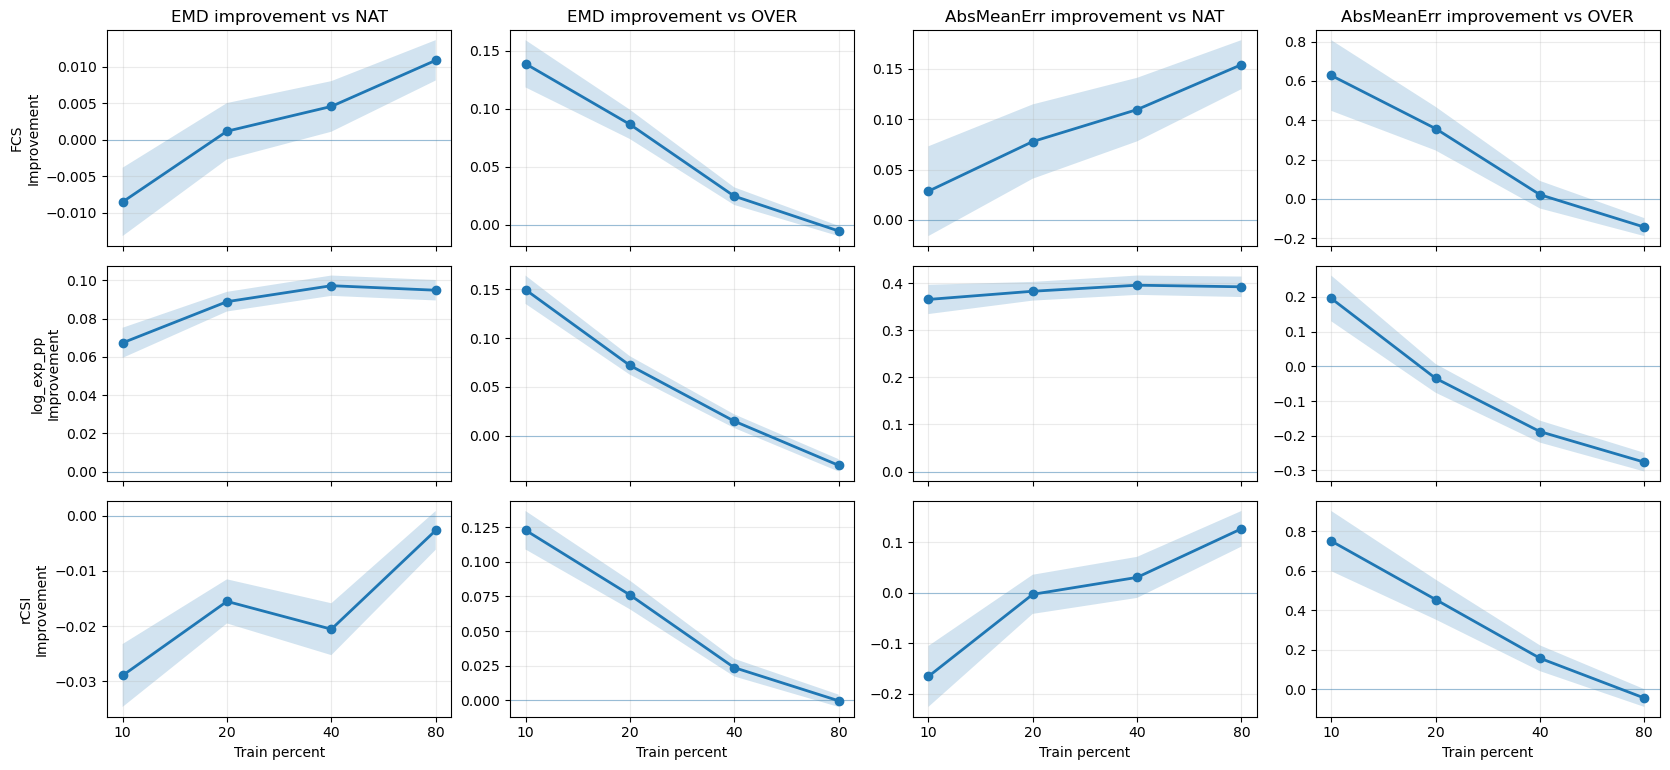

In [7]:
targets = sorted(adm1_avg["target"].unique())
nrows = len(targets)
ncols = len(COMBOS)

fig_w = 4.2 * ncols
fig_h = max(2.6 * nrows, 3.2)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=True)

if nrows == 1:
    axes = np.array([axes])

for r, target in enumerate(targets):
    for c, (metric, baseline) in enumerate(COMBOS):
        ax = axes[r, c]
        sub = adm1_avg[(adm1_avg["target"] == target) & (adm1_avg["metric"] == metric) & (adm1_avg["baseline"] == baseline)]
        sub = sub.sort_values("train_percent")

        x = sub["train_percent"].to_numpy()
        y = sub["mean"].to_numpy()
        se = sub["se"].to_numpy()

        ax.plot(x, y, marker="o", linewidth=2.0)
        ax.fill_between(x, y - se, y + se, alpha=0.2)

        if r == 0:
            ax.set_title(combo_titles[(metric, baseline)])
        if c == 0:
            ax.set_ylabel(f"{target}\nImprovement")
        ax.axhline(0, linewidth=0.8, alpha=0.4)
        ax.grid(True, alpha=0.25)

for ax in axes[-1, :]:
    ax.set_xlabel("Train percent")

fig.tight_layout()
plt.show()

In [8]:
overall_avg = aggregate_means_with_se(
    adm1_avg,
    group_cols=["train_percent","metric","baseline"]
).sort_values(["metric","baseline","train_percent"]).reset_index(drop=True)

overall_avg

/tmp/ipykernel_155552/1536647084.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, as_index=False).apply(_agg).reset_index(drop=True)


,train_percent,metric,baseline,mean,se,n
0,10,absmeanerr,nat,0.076096,0.027044,3.0
1,20,absmeanerr,nat,0.152497,0.019013,3.0
2,40,absmeanerr,nat,0.178530,0.018458,3.0
3,80,absmeanerr,nat,0.224335,0.016004,3.0
4,10,absmeanerr,over,0.524880,0.081553,3.0
5,20,absmeanerr,over,0.259336,0.051891,3.0
6,40,absmeanerr,over,-0.002945,0.033631,3.0
7,80,absmeanerr,over,-0.154402,0.023175,3.0
8,10,emd,nat,0.009949,0.003595,3.0
9,20,emd,nat,0.024820,0.002519,3.0


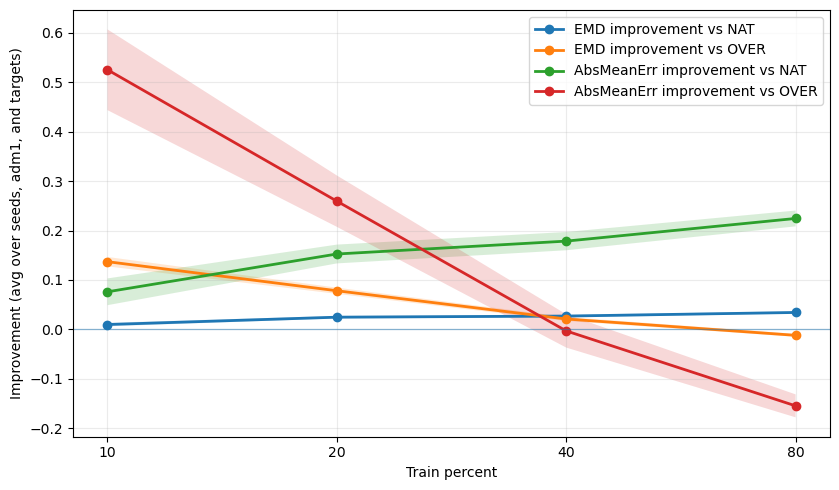

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))

for (metric, baseline) in COMBOS:
    sub = overall_avg[(overall_avg["metric"] == metric) & (overall_avg["baseline"] == baseline)].sort_values("train_percent")
    x = sub["train_percent"].to_numpy()
    y = sub["mean"].to_numpy()
    se = sub["se"].to_numpy()

    label = combo_titles[(metric, baseline)]
    ax.plot(x, y, marker="o", linewidth=2.0, label=label)
    ax.fill_between(x, y - se, y + se, alpha=0.18)

ax.axhline(0, linewidth=0.9, alpha=0.5)
ax.set_xlabel("Train percent")
ax.set_ylabel("Improvement (avg over seeds, adm1, and targets)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## what componend guides the trend?

In [10]:
import numpy as np
import pandas as pd

# Focus: absmeanerr, baseline=over
sub = raw[[
    "seed","train_percent","adm1_code","adm1_name","target",
    "absmeanerr_gen","absmeanerr_over"
]].copy()

# Ensure numeric
sub["absmeanerr_gen"]  = pd.to_numeric(sub["absmeanerr_gen"], errors="coerce")
sub["absmeanerr_over"] = pd.to_numeric(sub["absmeanerr_over"], errors="coerce")

# Improvement definition consistent with earlier: baseline - gen
sub["improvement"] = sub["absmeanerr_over"] - sub["absmeanerr_gen"]

sub.head()

,seed,train_percent,adm1_code,adm1_name,target,absmeanerr_gen,absmeanerr_over,improvement
0,1,10,Abyan,Abyan,log_exp_pp,0.208753,0.903655,0.694901
1,1,10,Abyan,Abyan,rCSI,0.845909,1.609238,0.763329
2,1,10,Abyan,Abyan,FCS,0.421942,0.268219,-0.153723
3,1,10,Ad Dali',Ad Dali',log_exp_pp,1.339819,1.255083,-0.084736
4,1,10,Ad Dali',Ad Dali',rCSI,0.304822,1.322266,1.017445


In [11]:
def mean_se(g, col):
    x = pd.to_numeric(g[col], errors="coerce").to_numpy()
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return pd.Series({"mean": np.nan, "se": np.nan, "n": 0})
    mean = float(np.mean(x))
    sd = float(np.std(x, ddof=1)) if n > 1 else 0.0
    se = sd / np.sqrt(n) if n > 0 else np.nan
    return pd.Series({"mean": mean, "se": se, "n": n})

group_cols = ["train_percent","target","adm1_code","adm1_name"]

seed_agg_components = (
    sub.groupby(group_cols, as_index=False)
       .apply(lambda g: pd.Series({
           "gen_mean": mean_se(g, "absmeanerr_gen")["mean"],
           "gen_se":   mean_se(g, "absmeanerr_gen")["se"],
           "over_mean": mean_se(g, "absmeanerr_over")["mean"],
           "over_se":   mean_se(g, "absmeanerr_over")["se"],
           "impr_mean": mean_se(g, "improvement")["mean"],
           "impr_se":   mean_se(g, "improvement")["se"],
           "n": int(np.isfinite(pd.to_numeric(g["improvement"], errors="coerce")).sum())
       }))
       .reset_index(drop=True)
)

seed_agg_components.head()

/tmp/ipykernel_155552/2187617646.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,train_percent,target,adm1_code,adm1_name,gen_mean,gen_se,over_mean,over_se,impr_mean,impr_se,n
0,10,FCS,Abyan,Abyan,0.721252,0.255866,0.737827,0.213110,0.016575,0.248015,5.0
1,10,FCS,Ad Dali',Ad Dali',1.239139,0.167154,1.340841,0.403955,0.101702,0.519545,5.0
2,10,FCS,Aden,Aden,1.122888,0.289619,2.185811,0.100999,1.062924,0.294347,5.0
3,10,FCS,Al Bayda,Al Bayda,1.190667,0.270394,0.585122,0.188181,-0.605545,0.411545,5.0
4,10,FCS,Al Hodeidah,Al Hodeidah,1.093059,0.124429,1.266944,0.508346,0.173885,0.551384,5.0


In [12]:
def avg_over_adm1_with_se(df, mean_col, se_col, group_cols):
    def _agg(g):
        means = g[mean_col].to_numpy(dtype=float)
        ses   = g[se_col].to_numpy(dtype=float)
        ok = np.isfinite(means)
        means = means[ok]
        ses = ses[ok]
        n = len(means)
        if n == 0:
            return pd.Series({"mean": np.nan, "se": np.nan, "n": 0})
        mean = float(np.mean(means))
        se = float(np.sqrt(np.sum(ses**2)) / n) if n > 0 else np.nan
        return pd.Series({"mean": mean, "se": se, "n": n})
    return df.groupby(group_cols, as_index=False).apply(_agg).reset_index(drop=True)

adm1_avg_gen = avg_over_adm1_with_se(seed_agg_components, "gen_mean", "gen_se", ["train_percent","target"])
adm1_avg_over = avg_over_adm1_with_se(seed_agg_components, "over_mean", "over_se", ["train_percent","target"])
adm1_avg_impr = avg_over_adm1_with_se(seed_agg_components, "impr_mean", "impr_se", ["train_percent","target"])

# Merge into one table
adm1_avg_components = (
    adm1_avg_gen.rename(columns={"mean":"gen_mean","se":"gen_se","n":"n_adm1_gen"})
    .merge(adm1_avg_over.rename(columns={"mean":"over_mean","se":"over_se","n":"n_adm1_over"}),
           on=["train_percent","target"], how="outer")
    .merge(adm1_avg_impr.rename(columns={"mean":"impr_mean","se":"impr_se","n":"n_adm1_impr"}),
           on=["train_percent","target"], how="outer")
    .sort_values(["target","train_percent"])
    .reset_index(drop=True)
)

adm1_avg_components.head()

/tmp/ipykernel_155552/2140085898.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, as_index=False).apply(_agg).reset_index(drop=True)
/tmp/ipykernel_155552/2140085898.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, as_index=False).apply(_agg).reset_index(drop=True)
/tmp/ipykernel_155552/2140085898.py:14: FutureWarning: DataFrameGroupBy.apply operated

,train_percent,target,gen_mean,gen_se,n_adm1_gen,over_mean,over_se,n_adm1_over,impr_mean,impr_se,n_adm1_impr
0,10,FCS,0.852634,0.046150,22.0,1.480021,0.164899,22.0,0.627387,0.179588,22.0
1,20,FCS,0.780035,0.039450,22.0,1.137374,0.096744,22.0,0.357339,0.110778,22.0
2,40,FCS,0.739822,0.032468,22.0,0.761442,0.064066,22.0,0.021620,0.070027,22.0
3,80,FCS,0.699119,0.022631,22.0,0.556145,0.041690,22.0,-0.142973,0.045683,22.0
4,10,log_exp_pp,0.598272,0.035422,22.0,0.794063,0.061968,22.0,0.195791,0.065885,22.0


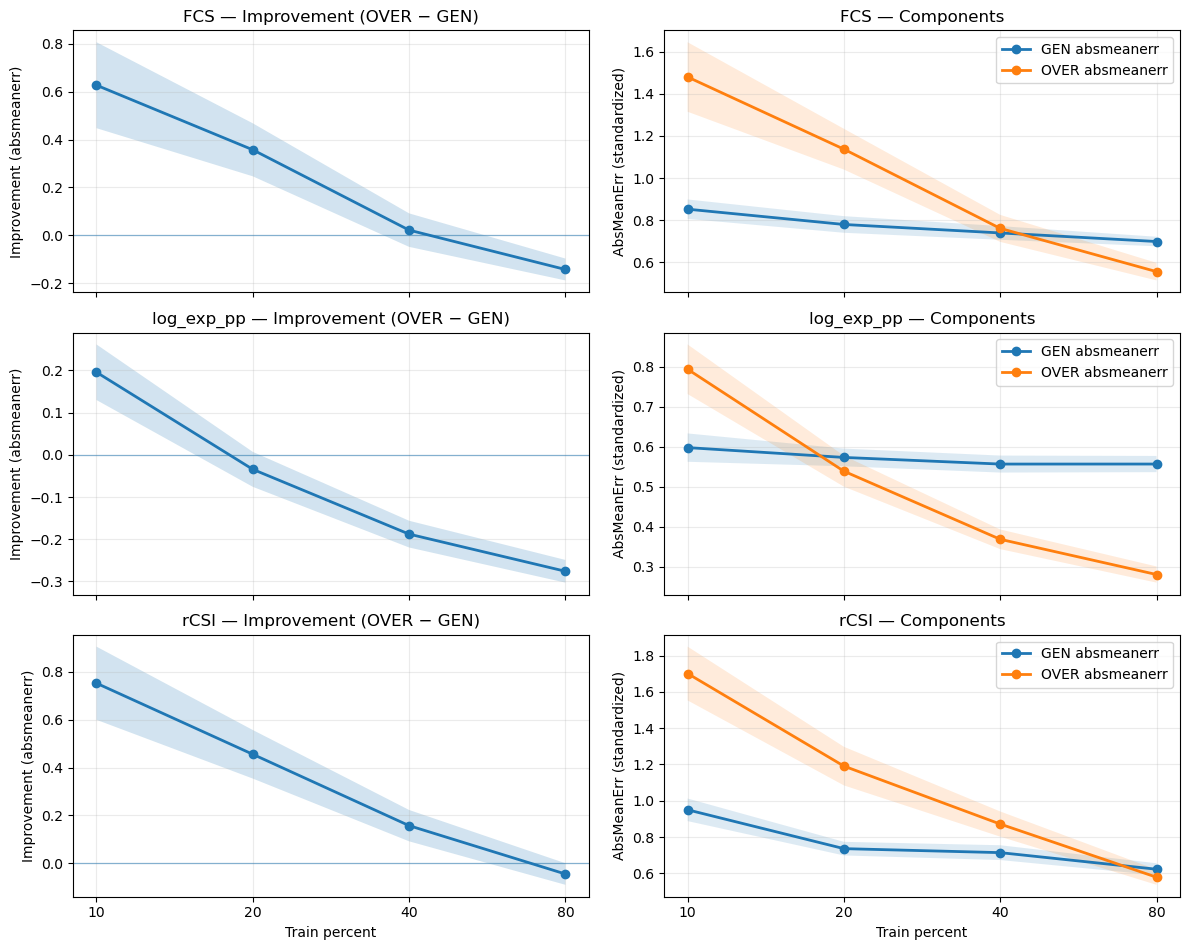

In [13]:
import matplotlib.pyplot as plt
import numpy as np

targets = sorted(adm1_avg_components["target"].unique())

fig, axes = plt.subplots(nrows=len(targets), ncols=2, figsize=(12, 3.2*len(targets)), sharex=True)

if len(targets) == 1:
    axes = np.array([axes])

for r, t in enumerate(targets):
    d = adm1_avg_components[adm1_avg_components["target"] == t].sort_values("train_percent")
    x = d["train_percent"].to_numpy()

    # --- left: improvement
    ax0 = axes[r, 0]
    y = d["impr_mean"].to_numpy()
    se = d["impr_se"].to_numpy()
    ax0.plot(x, y, marker="o", linewidth=2.0)
    ax0.fill_between(x, y-se, y+se, alpha=0.2)
    ax0.axhline(0, linewidth=0.9, alpha=0.5)
    ax0.set_title(f"{t} — Improvement (OVER − GEN)")
    ax0.set_ylabel("Improvement (absmeanerr)")
    ax0.grid(True, alpha=0.25)

    # --- right: components
    ax1 = axes[r, 1]
    y_g = d["gen_mean"].to_numpy()
    se_g = d["gen_se"].to_numpy()
    y_b = d["over_mean"].to_numpy()
    se_b = d["over_se"].to_numpy()

    ax1.plot(x, y_g, marker="o", linewidth=2.0, label="GEN absmeanerr")
    ax1.fill_between(x, y_g-se_g, y_g+se_g, alpha=0.15)

    ax1.plot(x, y_b, marker="o", linewidth=2.0, label="OVER absmeanerr")
    ax1.fill_between(x, y_b-se_b, y_b+se_b, alpha=0.15)

    ax1.set_title(f"{t} — Components")
    ax1.set_ylabel("AbsMeanErr (standardized)")
    ax1.grid(True, alpha=0.25)
    ax1.legend()

for ax in axes[-1, :]:
    ax.set_xlabel("Train percent")

plt.tight_layout()
plt.show()

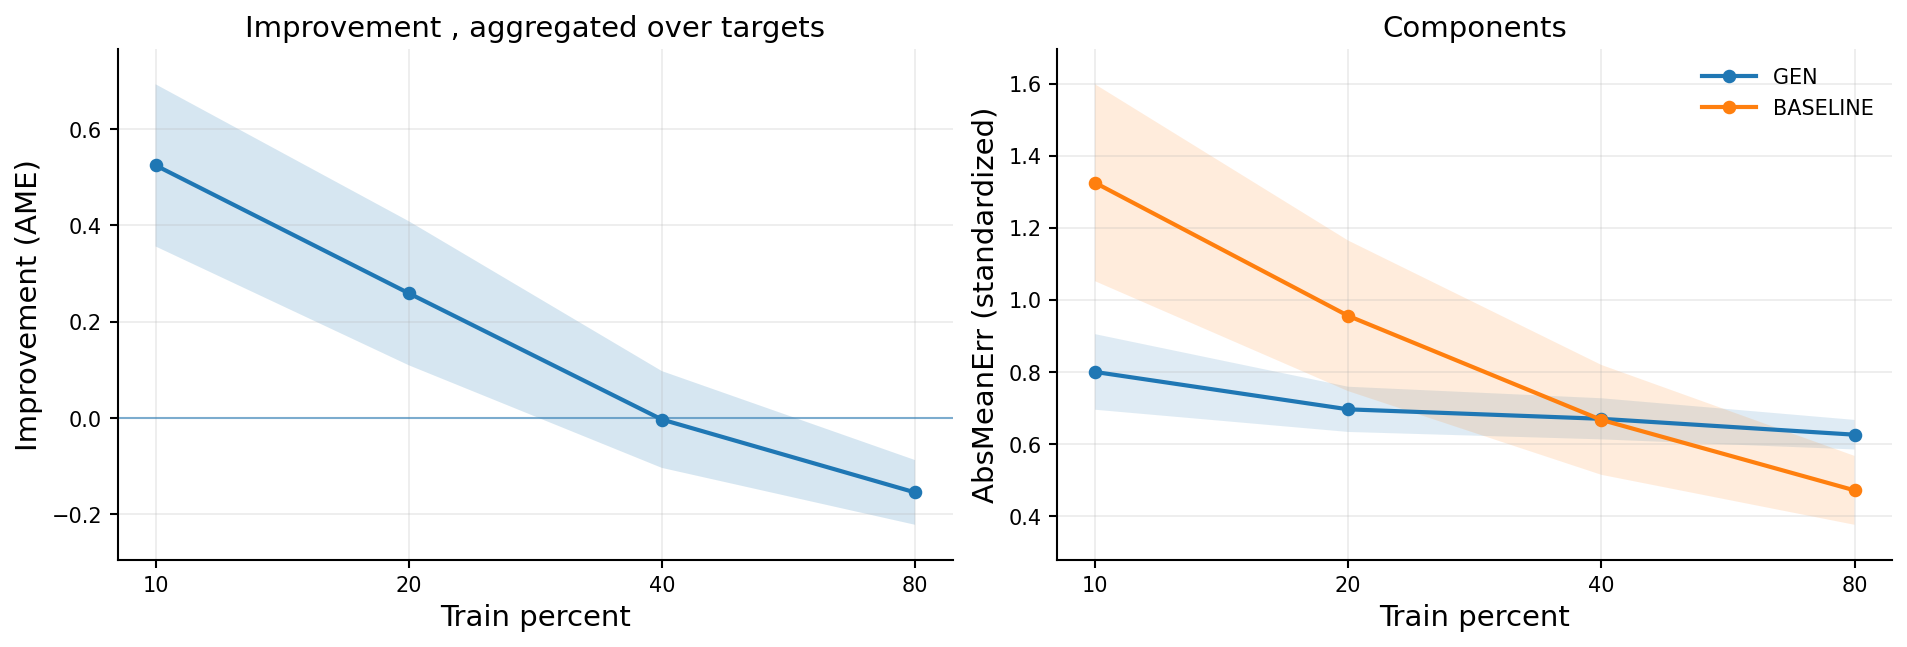

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Aggregate across targets
# ----------------------------
def _se(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(n)

n_targets = adm1_avg_components["target"].nunique()

agg = (
    adm1_avg_components
    .groupby("train_percent", as_index=False)
    .agg(
        impr_mean=("impr_mean", "mean"),
        impr_se=("impr_mean", lambda s: _se(s.to_numpy())),
        gen_mean=("gen_mean", "mean"),
        gen_se=("gen_mean", lambda s: _se(s.to_numpy())),
        over_mean=("over_mean", "mean"),
        over_se=("over_mean", lambda s: _se(s.to_numpy())),
    )
    .sort_values("train_percent")
)

x = agg["train_percent"].to_numpy()

# ----------------------------
# Paper-ready style (no explicit colors)
# ----------------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.25,
})

def _despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def _nice_limits(ax, y, pad_frac=0.08):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return
    ymin, ymax = float(y.min()), float(y.max())
    if np.isclose(ymin, ymax):
        pad = 1.0 if np.isclose(ymin, 0.0) else abs(ymin) * 0.1
    else:
        pad = (ymax - ymin) * pad_frac
    ax.set_ylim(ymin - pad, ymax + pad)

# ----------------------------
# Plot
# ----------------------------
fig, (ax0, ax1) = plt.subplots(
    nrows=1, ncols=2,
    figsize=(12.6, 4.2),
    constrained_layout=True,
    sharex=True
)

# Left: improvement
y = agg["impr_mean"].to_numpy()
se = agg["impr_se"].to_numpy()

ax0.plot(x, y, marker="o")
ax0.fill_between(x, y - se, y + se, alpha=0.18, linewidth=0)
ax0.axhline(0, linewidth=1.0, alpha=0.55)
ax0.set_title("Improvement , aggregated over targets", fontsize=14)
ax0.set_ylabel("Improvement (AME)", fontsize=14)
ax0.set_xlabel("Train percent", fontsize=14)
ax0.grid(True)
ax0.tick_params(direction="out", length=4, width=1)
_despine(ax0)
_nice_limits(ax0, np.r_[y - se, y + se])

# Right: components
y_g = agg["gen_mean"].to_numpy()
se_g = agg["gen_se"].to_numpy()
y_o = agg["over_mean"].to_numpy()
se_o = agg["over_se"].to_numpy()

ax1.plot(x, y_g, marker="o", label="GEN ", )
ax1.fill_between(x, y_g - se_g, y_g + se_g, alpha=0.14, linewidth=0)

ax1.plot(x, y_o, marker="o", label="BASELINE")
ax1.fill_between(x, y_o - se_o, y_o + se_o, alpha=0.14, linewidth=0)

ax1.set_title("Components", fontsize=14)
ax1.set_ylabel("AbsMeanErr (standardized)", fontsize=14)
ax1.set_xlabel("Train percent", fontsize=14)
ax1.grid(True)
ax1.tick_params(direction="out", length=4, width=1)
_despine(ax1)
_nice_limits(ax1, np.r_[y_g - se_g, y_g + se_g, y_o - se_o, y_o + se_o])

leg = ax1.legend(frameon=False, loc="best", handlelength=2.6)



plt.show()

# Optional: save a high-res, publication-friendly file
# fig.savefig("adm1_components_aggregated.pdf", bbox_inches="tight")
# fig.savefig("adm1_components_aggregated.png", bbox_inches="tight")